# Project Overview
This experiment aims to uncover several findings and develop AI model related to Profile Matching and Recommendation.

## Import data & data inspection

In [ ]:
import kagglehub
import os
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from sklearn.metrics import accuracy_score
import re
import string
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
import tensorflow.keras.layers as layers
from tensorflow.keras.models import Sequential,Model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [ ]:
path = kagglehub.dataset_download("debabratakuiry/profile-matching-and-recommendation-dataset")
print("Path to dataset files:", path)
print('Files in the path:',os.listdir(path))

Using Colab cache for faster access to the 'profile-matching-and-recommendation-dataset' dataset.
Path to dataset files: /kaggle/input/profile-matching-and-recommendation-dataset
Files in the path: ['feedback.csv', 'users.csv']


In [ ]:
user_df = pd.read_csv(path+'/users.csv')
feedback_df = pd.read_csv(path+'/feedback.csv')

### User data inspection

In [ ]:
user_df

,user_id,name,age,location,profession,experience_years,professional_summary,about_me,mbti,interests
0,U001,Rahul Sharma,28,Bangalore,Software Engineer,5,Backend engineer with expertise in Python and ...,I enjoy solving complex technical problems and...,INTJ,"Coding,Open Source,Hiking,Reading"
1,U002,Priya Nair,26,Mumbai,Data Analyst,3,Data analyst with a strong foundation in SQL a...,I am curious by nature and love digging into d...,INFJ,"Data Science,Yoga,Travel,Photography"
2,U003,Arjun Mehta,32,Delhi,Product Manager,8,Product manager with experience leading cross-...,I am a strategic thinker who thrives in ambigu...,ENTJ,"Product Strategy,Cycling,Reading,Podcasts"
3,U004,Sneha Reddy,24,Hyderabad,UX Designer,2,Junior UX designer with a strong eye for visua...,I am a creative and empathetic individual who ...,ENFP,"Design,Photography,Travel,Art"
4,U005,Rohit Verma,35,Pune,DevOps Engineer,10,DevOps engineer with a decade of experience in...,I am methodical and detail-oriented with a pas...,ISTJ,"Automation,Trekking,Astronomy,Gaming"
...,...,...,...,...,...,...,...,...,...,...
95,U096,Arpit Tiwari,30,Lucknow,Cybersecurity Analyst,7,Cybersecurity engineer with expertise in SOC o...,"I am alert, systematic, and thrive on the chal...",INTJ,"Threat Intelligence,Chess,Running,Reading"
96,U097,Gauri Saxena,28,Delhi,Marketing Specialist,5,Brand and communications specialist with exper...,"I am articulate, strategic, and passionate abo...",ENFJ,"PR,Music,Dance,Reading"
97,U098,Rakesh Nair,34,Kochi,Financial Analyst,10,Senior financial analyst with expertise in pro...,"I am analytical, detail-oriented, and motivate...",INTJ,"Green Finance,Swimming,Trekking,Reading"
98,U099,Sheetal Mishra,41,Bhopal,Teacher,17,Senior educator and school curriculum coordina...,"I am nurturing, creative, and believe that gre...",ISFJ,"Literature,Poetry,Gardening,Music"


In [ ]:
user_df[['age']].value_counts()

,count
age,
27,10
28,9
29,8
30,8
26,7
25,6
31,6
33,6
32,5


### Feedback data inspection

In [ ]:
feedback_df

,user_id,matched_user_id,action,timestamp
0,U099,U097,1,2025-02-22
1,U084,U074,1,2024-07-08
2,U011,U062,1,2024-11-21
3,U070,U079,1,2025-02-18
4,U005,U097,0,2024-08-10
...,...,...,...,...
746,U089,U018,1,2025-03-16
747,U100,U072,1,2024-07-03
748,U088,U016,1,2024-11-18
749,U020,U057,1,2025-03-23


### What we can do with this data?
From data we inspected above, we gonna try to answer several questions:
- is personal traits description correlated with MBTI?
- can personal traits and MBTI used to match another person?

## Experiment 1: Personal Trait Description (PTD) and MBTI Correlation
We will train custom model and use PTD as input to predict the MBTI category. If the model successfully achieve higher accuracy compared to model with randomize data, it means PTD has correlation with MBTI.

### Preprocess data

In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2026-06-02 15:25:58--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-06-02 15:25:58--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-06-02 15:25:58--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=10000,
    output_mode='int',
    output_sequence_length=40,
)

In [ ]:
# preprocess data
corpus = []
y = []
for idx,row in user_df.iterrows():
    # text cleaning
    text = row['about_me'].lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\W+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # tokenized and stop words removal
    tokenized = word_tokenize(text)
    tokenized = [word for word in tokenized if word not in stop_words]

    # lemmatization
    tokenized = [lemmatizer.lemmatize(word,pos="v") for word in tokenized]

    # stem
    # tokenized = [stemmer.stem(word) for word in tokenized]

    # save
    corpus.append(' '.join(tokenized))

    # label processing
    mbti = []
    mbti_text = row['mbti'].upper()
    mbti.append(1 if mbti_text[0] == 'E' else 0)
    mbti.append(1 if mbti_text[1] == 'S' else 0)
    mbti.append(1 if mbti_text[2] == 'T' else 0)
    mbti.append(1 if mbti_text[3] == 'J' else 0)
    y.append(mbti)


vectorize_layer.adapt(corpus)
x = np.array(vectorize_layer(corpus))
y = np.array(y)
print('X Shape:',x.shape)
print('Y Shape:',y.shape)

X Shape: (100, 40)
Y Shape: (100, 4)


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=42)
print('X train Shape:',x_train.shape)
print('Y train Shape:',y_train.shape)
print('X test Shape:',x_test.shape)
print('Y test Shape:',y_test.shape)

X train Shape: (70, 40)
Y train Shape: (70, 4)
X test Shape: (30, 40)
Y test Shape: (30, 4)


### Model training (with valid data)

In [ ]:
vocab = vectorize_layer.get_vocabulary()
embedding_dim = 100
num_tokens = len(vectorize_layer.get_vocabulary())
embeddings_index = {}
word_index = dict(zip(vocab, range(len(vocab))))

with open(f'glove.6B.{embedding_dim}d.txt', encoding="utf-8") as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

embedding_matrix = np.zeros((num_tokens, embedding_dim))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [ ]:
model = Sequential([
    layers.Input(shape=x.shape[1:]),
    layers.Embedding(
        input_dim=num_tokens,
        output_dim=embedding_dim,
        embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
        trainable=False,
        mask_zero=True,
        ),
    layers.Bidirectional(
        layers.LSTM(128,return_sequences=True)
    ),
    layers.GlobalMaxPool1D(),
    layers.Dense(64,activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32,activation='relu'),
    layers.Dense(y.shape[-1],activation='sigmoid'),
])
model.compile(tf.keras.optimizers.Adam(0.001),'binary_crossentropy',metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pooling1d_44' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "sequential_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_52 (Embedding)        │ (None, 40, 100)        │        71,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_46                │ (None, 40, 256)        │       234,496 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_44         │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_150 (Dense)               │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_151 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_152 (Dense)               │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 324,956 (1.24 MB)

 Trainable params: 253,156 (988.89 KB)

 Non-trainable params: 71,800 (280.47 KB)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 400ms/step - accuracy: 0.2714 - loss: 0.7076 - val_accuracy: 0.1667 - val_loss: 0.6881
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.2429 - loss: 0.6821 - val_accuracy: 0.1667 - val_loss: 0.6787
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.2429 - loss: 0.6763 - val_accuracy: 0.1667 - val_loss: 0.6787
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.2429 - loss: 0.6626 - val_accuracy: 0.1667 - val_loss: 0.6760
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.2429 - loss: 0.6605 - val_accuracy: 0.1667 - val_loss: 0.6710
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.2714 - loss: 0.6451 - val_accuracy: 0.1667 - val_loss: 0.6606
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.2571 - loss: 0.6354 - val_accuracy: 0.1667 - val_loss: 0.6531
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.3143 - loss: 0.6162 - val_accuracy: 0.1667 - val_loss:

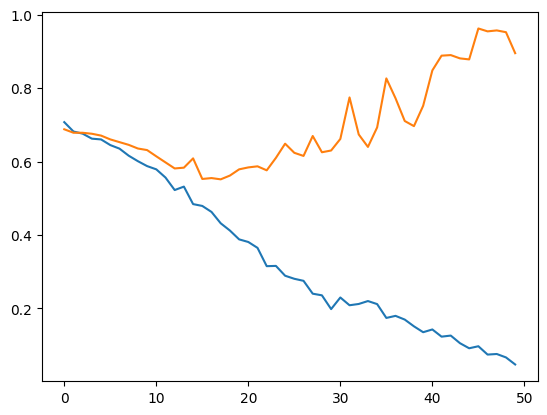

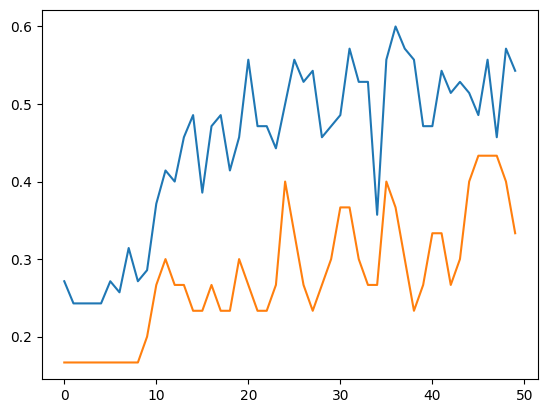

In [ ]:
history = model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=50,batch_size=32)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()

In [ ]:
print('Max accuracy:',max(history.history['val_accuracy']))

Max accuracy: 0.4333333373069763


### Model training (with invalid data)

In [ ]:
np.random.shuffle(y)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=42)
print('X train Shape:',x_train.shape)
print('Y train Shape:',y_train.shape)
print('X test Shape:',x_test.shape)
print('Y test Shape:',y_test.shape)

X train Shape: (70, 40)
Y train Shape: (70, 4)
X test Shape: (30, 40)
Y test Shape: (30, 4)


In [ ]:
model = Sequential([
    layers.Input(shape=x.shape[1:]),
    layers.Embedding(
        input_dim=num_tokens,
        output_dim=embedding_dim,
        embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
        trainable=False,
        mask_zero=True,
        ),
    layers.Bidirectional(
        layers.LSTM(128,return_sequences=True)
    ),
    layers.GlobalMaxPool1D(),
    layers.Dense(64,activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32,activation='relu'),
    layers.Dense(y.shape[-1],activation='sigmoid'),
])
model.compile(tf.keras.optimizers.Adam(0.001),'binary_crossentropy',metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pooling1d_43' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "sequential_39"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_51 (Embedding)        │ (None, 40, 100)        │        71,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_45                │ (None, 40, 256)        │       234,496 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_43         │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_147 (Dense)               │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_148 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_149 (Dense)               │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 324,956 (1.24 MB)

 Trainable params: 253,156 (988.89 KB)

 Non-trainable params: 71,800 (280.47 KB)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 464ms/step - accuracy: 0.2286 - loss: 0.7113 - val_accuracy: 0.0333 - val_loss: 0.6944
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.1857 - loss: 0.6850 - val_accuracy: 0.0667 - val_loss: 0.6939
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.1714 - loss: 0.6773 - val_accuracy: 0.0333 - val_loss: 0.6906
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.2143 - loss: 0.6644 - val_accuracy: 0.1333 - val_loss: 0.6874
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.2429 - loss: 0.6562 - val_accuracy: 0.1667 - val_loss: 0.6893
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.2571 - loss: 0.6648 - val_accuracy: 0.1667 - val_loss: 0.6950
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.2571 - loss: 0.6452 - val_accuracy: 0.1667 - val_loss: 0.6934
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.2571 - loss: 0.6392 - val_accuracy: 0.0667 - val_loss:

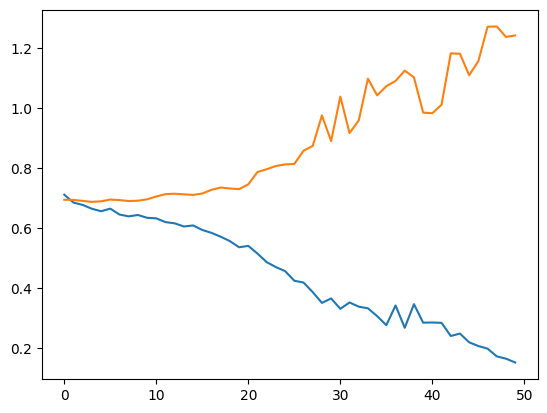

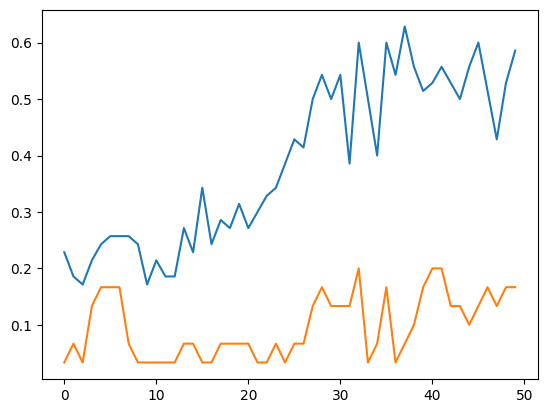

In [ ]:
history = model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=50,batch_size=32)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()

In [ ]:
print('Max accuracy:',max(history.history['val_accuracy']))

Max accuracy: 0.20000000298023224


### Result
The model that trained with valid data achieve accuracy 43% which is higher than model with invalid data that achieve accuracy 20%. This indicate that PTD and MBTI is kinda correlated. Even though the accuracy is far from 'good', this might be occured due to small sample or insufficient model architecture or pre-trained embedding.

The validation loss value also increasing on both experiment despite the training losses are decreasing. This might indicate that the model is start overfitting.

## Experiment 2: Matching 2 PTD + MBTI information
We will train custom model like experiment 1 and use 2 different persons PTD + MBTI as input and output binary classification (match or not).

### Data Preprocessing

In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2026-06-06 07:09:32--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-06-06 07:09:32--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-06-06 07:09:33--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=10000,
    output_mode='int',
    output_sequence_length=60,
)

In [ ]:
def preproc_text(txt):
    # text cleaning
    text = txt.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\W+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # tokenized and stop words removal
    tokenized = word_tokenize(text)
    tokenized = [word for word in tokenized if word not in stop_words]

    # lemmatization
    tokenized = [lemmatizer.lemmatize(word,pos="v") for word in tokenized]

    # stem
    # tokenized = [stemmer.stem(word) for word in tokenized]
    return tokenized

In [ ]:
# preprocess data
corpus1 = []
corpus2 = []
corpus = []
y = []
for idx,row in feedback_df.iterrows():
    first_user = user_df.loc[user_df['user_id'] == row['user_id']]
    target_user = user_df.loc[user_df['user_id'] == row['matched_user_id']]


    tokenized1 = preproc_text(first_user['about_me'].values[0])
    tokenized2 = preproc_text(target_user['about_me'].values[0])
    tokenized = tokenized1 + tokenized2

    # save
    corpus.append(' '.join(tokenized))
    corpus1.append(' '.join(tokenized1))
    corpus2.append(' '.join(tokenized2))
    y.append(row['action'])


vectorize_layer.adapt(corpus)
x = []
corp = np.array([vectorize_layer(corpus1),vectorize_layer(corpus2)])
for i in range(len(corpus1)):
    x.append(np.array([corp[0,i,:],corp[1,i,:]]))
x = np.array(x)
y = np.array(y)
print('X Shape:',x.shape)
print('Y Shape:',y.shape)

X Shape: (751, 2, 60)
Y Shape: (751,)


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=42)
print('X train Shape:',x_train.shape)
print('Y train Shape:',y_train.shape)
print('X test Shape:',x_test.shape)
print('Y test Shape:',y_test.shape)

X train Shape: (525, 2, 60)
Y train Shape: (525,)
X test Shape: (226, 2, 60)
Y test Shape: (226,)


### Model Training

In [ ]:
vocab = vectorize_layer.get_vocabulary()
embedding_dim = 100
num_tokens = len(vectorize_layer.get_vocabulary())
embeddings_index = {}
word_index = dict(zip(vocab, range(len(vocab))))

with open(f'glove.6B.{embedding_dim}d.txt', encoding="utf-8") as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

embedding_matrix = np.zeros((num_tokens, embedding_dim))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [ ]:
def build_model(in_shape,out_shape):
    input = layers.Input(shape=in_shape)
    t1 = input[:,0]
    t2 = input[:,1]

    # define layers
    emb_obj = layers.Embedding(
        input_dim=num_tokens,
        output_dim=embedding_dim,
        embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
        trainable=False,
        mask_zero=True,
    )
    lstm_obj = layers.Bidirectional(
        layers.LSTM(128,return_sequences=True)
    )
    glob_obj = layers.GlobalMaxPool1D()

    # process inputs
    emb1 = emb_obj(t1)
    emb1 = lstm_obj(emb1)
    emb1 = glob_obj(emb1)

    emb2 = emb_obj(t2)
    emb2 = lstm_obj(emb2)
    emb2 = glob_obj(emb2)

    # concat
    out = layers.Concatenate()([emb1,emb2])
    out = layers.Dense(64,activation='relu')(out)
    out = layers.Dropout(0.3)(out)
    out = layers.Dense(32,activation='relu')(out)
    out = layers.Dense(out_shape,activation='sigmoid')(out)

    model = Model(inputs=input,outputs=out)

    return model

model = build_model(x.shape[1:],1)
model.compile(tf.keras.optimizers.Adam(0.001),'binary_crossentropy',metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pooling1d_49' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_49"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_55      │ (None, 2, 60)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_28         │ (None, 60)        │          0 │ input_layer_55[0… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_29         │ (None, 60)        │          0 │ input_layer_55[0… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_57        │ (None, 60, 100)   │     71,800 │ get_item_28[0][0… │
│ (Embedding)         │                   │            │ get_item_29[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_69        │ (None, 60)        │          0 │ get_item_28[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_70        │ (None, 60)        │          0 │ get_item_29[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_53    │ (None, 60, 256)   │    234,496 │ embedding_57[0][… │
│ (Bidirectional)     │                   │            │ not_equal_69[0][… │
│                     │                   │            │ embedding_57[1][… │
│                     │                   │            │ not_equal_70[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ bidirectional_53… │
│ (GlobalMaxPooling1… │                   │            │ bidirectional_53… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_14      │ (None, 512)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_165 (Dense)   │ (None, 64)        │     32,832 │ concatenate_14[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_55          │ (None, 64)        │          0 │ dense_165[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_166 (Dense)   │ (None, 32)        │      2,080 │ dropout_55[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_167 (Dense)   │ (None, 1)         │         33 │ dense_166[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 341,241 (1.30 MB)

 Trainable params: 269,441 (1.03 MB)

 Non-trainable params: 71,800 (280.47 KB)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 484ms/step - accuracy: 0.5752 - loss: 0.6868 - val_accuracy: 0.5929 - val_loss: 0.6805
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 383ms/step - accuracy: 0.5962 - loss: 0.6666 - val_accuracy: 0.5929 - val_loss: 0.6815
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 416ms/step - accuracy: 0.6019 - loss: 0.6687 - val_accuracy: 0.5929 - val_loss: 0.6845
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 427ms/step - accuracy: 0.6057 - loss: 0.6604 - val_accuracy: 0.5929 - val_loss: 0.6894
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 351ms/step - accuracy: 0.6095 - loss: 0.6497 - val_accuracy: 0.5708 - val_loss: 0.6950
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 497ms/step - accuracy: 0.6381 - loss: 0.6438 - val_accuracy: 0.5929 - val_loss: 0.7042
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 382ms/step - accuracy: 0.6362 - loss: 0.6229 - val_accuracy: 0.4690 - val_loss: 0.7205
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 527ms/step - accuracy: 0.6648 - loss: 0.6171 - val_accuracy: 

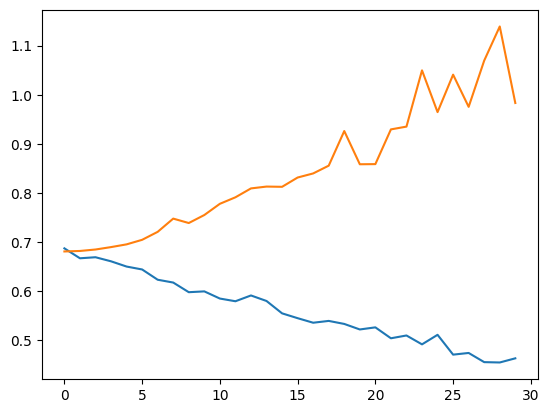

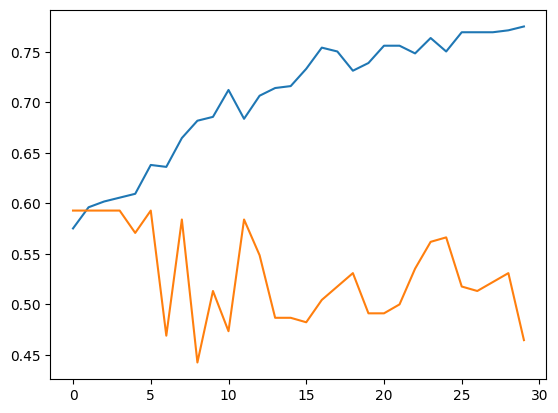

In [ ]:
history = model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=30,batch_size=32)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()

### Conclusion
It looks like the model failed to predict the match between 2 persons.This may be due to biased data.

## Final Thought
Based on 2 experiments we've done before, the Personal Trait Description and MBTI are kinda correlated. Despite the model overfitting, this might happen due to low samples or insufficient pre-trained embedding model. On the other hand, compare 2 persons PTD and MBTI information to check are they match or not, looks like it doesn't work. This may be due to biased data or poor model architecture.